# NLP & representation learning: Neural Embeddings, Text Classification


To use statistical classifiers with text, it is first necessary to vectorize the text. In the first practical session we explored the **Bag of Word (BoW)** model.

Modern **state of the art** methods uses  embeddings to vectorize the text before classification in order to avoid feature engineering.

## [Dataset](https://thome.isir.upmc.fr/classes/RITAL/json_pol.json)


## "Modern" NLP pipeline

By opposition to the **bag of word** model, in the modern NLP pipeline everything is **embeddings**. Instead of encoding a text as a **sparse vector** of length $D$ (size of feature dictionnary) the goal is to encode the text in a meaningful dense vector of a small size $|e| <<< |D|$.


The raw classification pipeline is then the following:

```
raw text ---|embedding table|-->  vectors --|Neural Net|--> class
```


### Using a  language model:

How to tokenize the text and extract a feature dictionnary is still a manual task. To directly have meaningful embeddings, it is common to use a pre-trained language model such as `word2vec` which we explore in this practical.

In this setting, the pipeline becomes the following:
```
      
raw text ---|(pre-trained) Language Model|--> vectors --|classifier (or fine-tuning)|--> class
```


- #### Classic word embeddings

 - [Word2Vec](https://arxiv.org/abs/1301.3781)
 - [Glove](https://nlp.stanford.edu/projects/glove/)


- #### bleeding edge language models techniques (see next)

 - [UMLFIT](https://arxiv.org/abs/1801.06146)
 - [ELMO](https://arxiv.org/abs/1802.05365)
 - [GPT](https://blog.openai.com/language-unsupervised/)
 - [BERT](https://arxiv.org/abs/1810.04805)






### Goal of this session:

1. Train word embeddings on training dataset
2. Tinker with the learnt embeddings and see learnt relations
3. Tinker with pre-trained embeddings.
4. Use those embeddings for classification
5. Compare different embedding models

## STEP 0: Loading data

In [1]:
import json
from collections import Counter

# Loading json
file = './json_pol.json'
with open(file,encoding="utf-8") as f:
    data = json.load(f)


# Quick Check
counter = Counter((x[1] for x in data))
print("Number of reviews : ", len(data))
print("----> # of positive : ", counter[1])
print("----> # of negative : ", counter[0])
print("")
print(data[0]) 

Number of reviews :  25000
----> # of positive :  12500
----> # of negative :  12500

['Although credit should have been given to Dr. Seuess for stealing the story-line of "Horton Hatches The Egg", this was a fine film. It touched both the emotions and the intellect. Due especially to the incredible performance of seven year old Justin Henry and a script that was sympathetic to each character (and each one\'s predicament), the thought provoking elements linger long after the tear jerking ones are over. Overall, superior acting from a solid cast, excellent directing, and a very powerful script. The right touches of humor throughout help keep a "heavy" subject from becoming tedious or difficult to sit through. Lastly, this film stands the test of time and seems in no way dated, decades after it was released.', 1]


## Word2Vec: Quick Recap

**[Word2Vec](https://arxiv.org/abs/1301.3781) is composed of two distinct language models (CBOW and SG), optimized to quickly learn word vectors**


given a random text: `i'm taking the dog out for a walk`



### (a) Continuous Bag of Word (CBOW)
    -  predicts a word given a context
    
maximizing `p(dog | i'm taking the ___ out for a walk)`
    
### (b) Skip-Gram (SG)               
    -  predicts a context given a word
    
 maximizing `p(i'm taking the out for a walk | dog)`



   

## STEP 1: train a language model (word2vec)

Gensim has one of [Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html) fastest implementation.


### Train:

In [2]:
# if gensim not installed yet
# ! pip install gensim

In [3]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

text = [t.split() for t,p in data]

# the following configuration is the default configuration
# cbow: p(dog | i'm taking the ___ out for a walk)
w2v = gensim.models.word2vec.Word2Vec(sentences=text, 
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=0, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

2026-02-16 19:37:14,801 : INFO : collecting all words and their counts
2026-02-16 19:37:14,802 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-16 19:37:15,144 : INFO : PROGRESS: at sentence #10000, processed 2301366 words, keeping 153853 word types
2026-02-16 19:37:15,450 : INFO : PROGRESS: at sentence #20000, processed 4553558 words, keeping 240043 word types
2026-02-16 19:37:15,611 : INFO : collected 276678 word types from a corpus of 5713167 raw words and 25000 sentences
2026-02-16 19:37:15,612 : INFO : Creating a fresh vocabulary
2026-02-16 19:37:15,731 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 48208 unique words (17.42% of original 276678, drops 228470)', 'datetime': '2026-02-16T19:37:15.731266', 'gensim': '4.4.0', 'python': '3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'prepare_vocab'}
2026-02-16 19:37:15,732 : INFO : Word2Vec lifecycl

In [4]:
# Worth it to save the previous embedding
w2v.save("W2v-movies.dat")
# You will be able to reload them:
w2v = gensim.models.Word2Vec.load("W2v-movies.dat")
# and you can continue the learning process if needed

2026-02-16 19:37:27,244 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'W2v-movies.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-02-16T19:37:27.244168', 'gensim': '4.4.0', 'python': '3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'saving'}
2026-02-16 19:37:27,244 : INFO : not storing attribute cum_table
2026-02-16 19:37:27,271 : INFO : saved W2v-movies.dat
2026-02-16 19:37:27,272 : INFO : loading Word2Vec object from W2v-movies.dat
2026-02-16 19:37:27,285 : INFO : loading wv recursively from W2v-movies.dat.wv.* with mmap=None
2026-02-16 19:37:27,285 : INFO : setting ignored attribute cum_table to None
2026-02-16 19:37:27,442 : INFO : Word2Vec lifecycle event {'fname': 'W2v-movies.dat', 'datetime': '2026-02-16T19:37:27.442448', 'gensim': '4.4.0', 'python': '3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-14.1-ar

## STEP 2: Test learnt embeddings

The word embedding space directly encodes similarities between words: the vector coding for the word "great" will be closer to the vector coding for "good" than to the one coding for "bad". Generally, [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) is the distance used when considering distance between vectors.

KeyedVectors have a built in [similarity](https://radimrehurek.com/gensim/models /keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.similarity) method to compute the cosine similarity between words

In [5]:
# is great really closer to good than to bad ?
print("great and good:",w2v.wv.similarity("great","good"))
print("great and bad:",w2v.wv.similarity("great","bad"))

great and good: 0.78230786
great and bad: 0.5193574


Since cosine distance encodes similarity, neighboring words are supposed to be similar. The [most_similar](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.most_similar) method returns the `topn` words given a query.

In [6]:
# The query can be as simple as a word, such as "movie"

# Try changing the word
w2v.wv.most_similar("movie",topn=5) # 5 most similar words
#w2v.wv.most_similar("awesome",topn=5)
#w2v.wv.most_similar("actor",topn=5)

[('film', 0.9234157204627991),
 ('movie,', 0.8235935568809509),
 ('film,', 0.7568167448043823),
 ('show', 0.7465260028839111),
 ('flick', 0.7388734817504883)]

But it can be a more complicated query
Word embedding spaces tend to encode much more.

The most famous exemple is: `vec(king) - vec(man) + vec(woman) => vec(queen)`

In [7]:
# What is awesome - good + bad ?
w2v.wv.most_similar(positive=["awesome","bad"],negative=["good"],topn=3)

w2v.wv.most_similar(positive=["actor","woman"],negative=["man"],topn=3) # do the famous exemple works for actor ?

w2v.wv.most_similar(positive=["actors","women"],negative=["men"],topn=3) # do the famous exemple works for actor ?


# Try other things like plurals for exemple.

[('actresses', 0.746368944644928),
 ('cast', 0.7075844407081604),
 ('actors,', 0.6695947051048279)]

**To test learnt "synctactic" and "semantic" similarities, Mikolov et al. introduced a special dataset containing a wide variety of three way similarities.**

**You can download the dataset [here](https://thome.isir.upmc.fr/classes/RITAL/questions-words.txt).**

In [8]:
out = w2v.wv.evaluate_word_analogies("questions-words.txt",case_insensitive=True)  #original semantic syntactic dataset.

2026-02-16 19:37:27,514 : INFO : Evaluating word analogies for top 300000 words in the model on questions-words.txt
2026-02-16 19:37:27,621 : INFO : capital-common-countries: 6.7% (6/90)
2026-02-16 19:37:27,718 : INFO : capital-world: 2.8% (2/71)
2026-02-16 19:37:27,753 : INFO : currency: 0.0% (0/28)
2026-02-16 19:37:28,153 : INFO : city-in-state: 0.0% (0/329)
2026-02-16 19:37:28,586 : INFO : family: 33.6% (115/342)
2026-02-16 19:37:29,756 : INFO : gram1-adjective-to-adverb: 1.6% (15/930)
2026-02-16 19:37:30,416 : INFO : gram2-opposite: 3.3% (18/552)
2026-02-16 19:37:31,981 : INFO : gram3-comparative: 22.2% (280/1260)
2026-02-16 19:37:32,855 : INFO : gram4-superlative: 6.1% (43/702)
2026-02-16 19:37:33,794 : INFO : gram5-present-participle: 15.6% (118/756)
2026-02-16 19:37:34,772 : INFO : gram6-nationality-adjective: 2.4% (19/792)
2026-02-16 19:37:36,346 : INFO : gram7-past-tense: 14.9% (188/1260)
2026-02-16 19:37:37,353 : INFO : gram8-plural: 4.8% (39/812)
2026-02-16 19:37:38,333 : IN

**When training the w2v models on the review dataset, since it hasn't been learnt with a lot of data, it does not perform very well.**


## Word2vec visualisation

2026-02-16 19:37:38,462 : INFO : NumExpr defaulting to 14 threads.


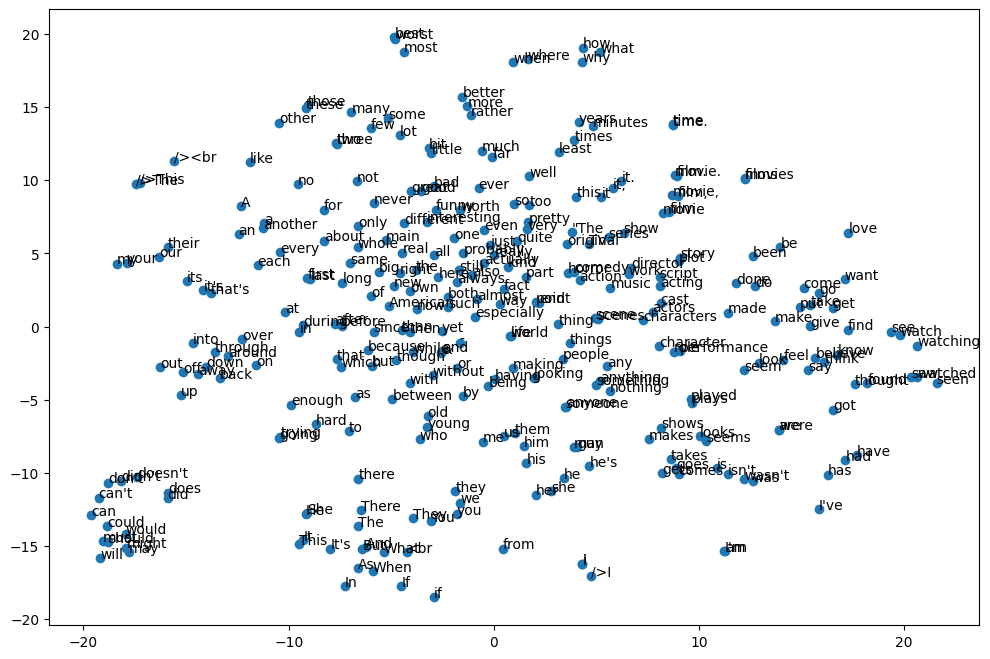

In [9]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

words = list(w2v.wv.index_to_key)[:300]
vectors = np.array([w2v.wv[word] for word in words])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]))


## STEP 3: Loading a pre-trained model

In Gensim, embeddings are loaded and can be used via the ["KeyedVectors"](https://radimrehurek.com/gensim/models/keyedvectors.html) class

> Since trained word vectors are independent from the way they were trained (Word2Vec, FastText, WordRank, VarEmbed etc), they can be represented by a standalone structure, as implemented in this module.

>The structure is called “KeyedVectors” and is essentially a mapping between entities and vectors. Each entity is identified by its string id, so this is a mapping between {str => 1D numpy array}.

>The entity typically corresponds to a word (so the mapping maps words to 1D vectors), but for some models, they key can also correspond to a document, a graph node etc. To generalize over different use-cases, this module calls the keys entities. Each entity is always represented by its string id, no matter whether the entity is a word, a document or a graph node.

**You can download the pre-trained word embedding [HERE](https://thome.isir.upmc.fr/classes/RITAL/word2vec-google-news-300.dat) .**

In [10]:
from gensim.test.utils import get_tmpfile
from gensim.models import KeyedVectors
import gensim.downloader as api

bload = True
fname = "word2vec-google-news-300"
sdir = "./" # Change

if(bload==True):
    wv_pre_trained = KeyedVectors.load(sdir+fname+".dat")
else:
    wv_pre_trained = api.load(fname)
    wv_pre_trained.save(sdir+fname+".dat")


2026-02-16 19:37:40,144 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-02-16 19:37:40,145 : INFO : built Dictionary<12 unique tokens: ['computer', 'human', 'interface', 'response', 'survey']...> from 9 documents (total 29 corpus positions)
2026-02-16 19:37:40,145 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<12 unique tokens: ['computer', 'human', 'interface', 'response', 'survey']...> from 9 documents (total 29 corpus positions)", 'datetime': '2026-02-16T19:37:40.145616', 'gensim': '4.4.0', 'python': '3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'created'}
2026-02-16 19:37:40,185 : INFO : loading KeyedVectors object from ./word2vec-google-news-300.dat
2026-02-16 19:37:41,438 : INFO : loading vectors from ./word2vec-google-news-300.dat.vectors.npy with mmap=None
2026-02-16 19:37:42,635 : INFO : KeyedVectors lifecycle event {'fname': './word2vec-google-news-300.dat', 'da

**Perform the "synctactic" and "semantic" evaluations again. Conclude on the pre-trained embeddings.**

Synctatic

In [11]:
out_pretrained = wv_pre_trained.evaluate_word_analogies("questions-words.txt",case_insensitive=True)  #original semantic syntactic dataset.

2026-02-16 19:37:42,837 : INFO : Evaluating word analogies for top 300000 words in the model on questions-words.txt
2026-02-16 19:37:54,737 : INFO : capital-common-countries: 83.2% (421/506)
2026-02-16 19:38:55,619 : INFO : capital-world: 81.3% (3552/4368)
2026-02-16 19:39:06,965 : INFO : currency: 28.5% (230/808)
2026-02-16 19:39:39,067 : INFO : city-in-state: 72.1% (1779/2467)
2026-02-16 19:39:44,397 : INFO : family: 86.2% (436/506)
2026-02-16 19:39:54,501 : INFO : gram1-adjective-to-adverb: 29.2% (290/992)
2026-02-16 19:40:02,920 : INFO : gram2-opposite: 43.5% (353/812)
2026-02-16 19:40:16,727 : INFO : gram3-comparative: 91.3% (1216/1332)
2026-02-16 19:40:28,679 : INFO : gram4-superlative: 88.0% (987/1122)
2026-02-16 19:40:39,512 : INFO : gram5-present-participle: 78.5% (829/1056)
2026-02-16 19:40:56,008 : INFO : gram6-nationality-adjective: 90.2% (1442/1599)
2026-02-16 19:41:12,198 : INFO : gram7-past-tense: 65.4% (1020/1560)
2026-02-16 19:41:26,099 : INFO : gram8-plural: 87.0% (11

Semantic

In [12]:
# is great really closer to good than to bad ?
print("great and good:",wv_pre_trained.similarity("great","good"))
print("great and bad:",wv_pre_trained.similarity("great","bad"))

great and good: 0.72915095
great and bad: 0.3928765


In [13]:
wv_pre_trained.most_similar(positive=["awesome","bad"],negative=["good"],topn=3)

wv_pre_trained.most_similar(positive=["actor","woman"],negative=["man"],topn=3) # do the famous exemple works for actor ?

wv_pre_trained.most_similar(positive=["actors","women"],negative=["men"],topn=3) # do the famous exemple works for actor ?


[('actresses', 0.701151967048645),
 ('Actors', 0.5886971950531006),
 ('thesps', 0.5436124205589294)]

In [14]:
w2v.wv.most_similar("movie",topn=5) # 5 most similar words

[('film', 0.9234157204627991),
 ('movie,', 0.8235935568809509),
 ('film,', 0.7568167448043823),
 ('show', 0.7465260028839111),
 ('flick', 0.7388734817504883)]

## STEP 4:  sentiment classification

In the previous practical session, we used a bag of word approach to transform text into vectors.
Here, we propose to try to use word vectors (previously learnt or loaded).


### <font color='green'> Since we have only word vectors and that sentences are made of multiple words, we need to aggregate them. </font>


### (1) Vectorize reviews using word vectors:

Word aggregation can be done in different ways:

- Sum
- Average
- Min/feature
- Max/feature

#### a few pointers:

- `w2v.wv.vocab` is a `set()` of the vocabulary (all existing words in your model)
- `np.minimum(a,b) and np.maximum(a,b)` respectively return element-wise min/max

In [15]:
import numpy as np
# We first need to vectorize text:
# First we propose to a sum of them

def vectorize(text,mean=False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """

    words = [word for word in text.split() if word in wv_pre_trained.key_to_index]
    
    vectors = np.array([wv_pre_trained[w] for w in words])
    
    return vectors.mean(axis=0) if mean else vectors.sum(axis=0)


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2)

classes = [p for text,pol in train]
X = [vectorize(text) for text,pol in train]
X_test = [vectorize(text) for text,pol in test]
true = [p for text,pol in test]

#let's see what a review vector looks like.
print(X[0])

[ 1.02719765e+01  2.72651958e+00  7.03316975e+00  2.36282883e+01
 -1.46180296e+01 -1.09982300e+00  1.61583710e+01 -1.66574650e+01
  1.67404480e+01  1.83024311e+01 -1.42580261e+01 -2.42973785e+01
 -5.45793152e+00  4.83820343e+00 -2.42274017e+01  1.24099693e+01
  1.53148041e+01  1.77432785e+01  4.66537476e-03 -1.33257675e+01
 -8.78397560e+00  9.86068344e+00  1.32012177e+00 -1.20288086e+00
  9.41338730e+00 -5.21293640e+00 -1.91687069e+01  1.35427246e+01
  7.61304092e+00 -3.59597015e+00 -9.72578335e+00  4.34101105e+00
 -1.51107025e+01  2.70586395e+00  7.62957764e+00 -3.44499207e+00
  5.53313255e+00 -3.21234131e+00  1.06750793e+01  1.56766090e+01
  2.22922344e+01 -5.35477829e+00  1.66934814e+01 -3.31241608e+00
 -6.83536530e+00 -4.50488377e+00 -9.60939026e+00  5.45298576e+00
  9.53804016e+00  3.01838303e+00  2.13499069e-01  1.02588921e+01
 -6.06949234e+00 -2.88845444e+00  2.07000732e+00  6.09394073e+00
 -2.97645569e+00 -1.64589996e+01  6.61103058e+00 -1.45763626e+01
 -3.38009644e+00  1.68006

### (2) Train a classifier
as in the previous practical session, train a logistic regression to do sentiment classification with word vectors



In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X, classes)
pred = clf.predict(X_test)
acc = accuracy_score(true, pred)
print("Pretrained Word2Vec Accuracy:", acc)

Pretrained Word2Vec Accuracy: 0.8404


In [18]:
def vectorize_movie(text, mean=True):
    words = [w.lower() for w in text.split()
             if w.lower() in w2v.wv.key_to_index]
    
    vectors = np.array([w2v.wv[w] for w in words])
    
    return vectors.mean(axis=0) if mean else vectors.sum(axis=0)

In [ ]:
train, test = train_test_split(data, test_size=0.2, random_state=42)
X_movie = np.array([vectorize_movie(text) for text, p in train])
X_test_movie = np.array([vectorize_movie(text) for text, p in test])
y_train = [p for text, p in train]
y_test = [p for text, p in test]

In [20]:
clf_movie = LogisticRegression(max_iter=1000)
clf_movie.fit(X_movie, y_train)
pred_movie = clf_movie.predict(X_test_movie)
acc_movie = accuracy_score(y_test, pred_movie)

print("Movie-trained Word2Vec Accuracy:", acc_movie)

Movie-trained Word2Vec Accuracy: 0.7832


performance should be worst than with bag of word (~80%). Sum/Mean aggregation does not work well on long reviews (especially with many frequent words). This adds a lot of noise.

## **Todo**:  Try answering the following questions:

- Which word2vec model works best: skip-gram or cbow

In [23]:
# CBOW: predicts word from context
# Skip-gram → predicts context from word
w2v_sg = gensim.models.Word2Vec(
    sentences=text,
    vector_size=100,
    window=5,
    min_count=5,
    workers=3,
    sg=1,    
    epochs=5
)

2026-02-16 19:42:40,053 : INFO : collecting all words and their counts
2026-02-16 19:42:40,054 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-16 19:42:40,351 : INFO : PROGRESS: at sentence #10000, processed 2301366 words, keeping 153853 word types
2026-02-16 19:42:40,721 : INFO : PROGRESS: at sentence #20000, processed 4553558 words, keeping 240043 word types
2026-02-16 19:42:40,907 : INFO : collected 276678 word types from a corpus of 5713167 raw words and 25000 sentences
2026-02-16 19:42:40,907 : INFO : Creating a fresh vocabulary
2026-02-16 19:42:41,029 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 48208 unique words (17.42% of original 276678, drops 228470)', 'datetime': '2026-02-16T19:42:41.028993', 'gensim': '4.4.0', 'python': '3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'prepare_vocab'}
2026-02-16 19:42:41,029 : INFO : Word2Vec lifecycl

In [ ]:
w2v_sg.save("W2v_sg-movies.dat")
w2v_sg = gensim.models.Word2Vec.load("W2v_sg-movies.dat")

2026-02-16 19:44:07,651 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'W2v_sg-movies.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-02-16T19:44:07.651415', 'gensim': '4.4.0', 'python': '3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'saving'}
2026-02-16 19:44:07,652 : INFO : not storing attribute cum_table
2026-02-16 19:44:07,678 : INFO : saved W2v_sg-movies.dat


In [25]:
out_sg = w2v_sg.wv.evaluate_word_analogies("questions-words.txt",case_insensitive=True)  #original semantic syntactic dataset.

2026-02-16 19:45:12,281 : INFO : Evaluating word analogies for top 300000 words in the model on questions-words.txt
2026-02-16 19:45:12,384 : INFO : capital-common-countries: 2.2% (2/90)
2026-02-16 19:45:12,472 : INFO : capital-world: 0.0% (0/71)
2026-02-16 19:45:12,505 : INFO : currency: 0.0% (0/28)
2026-02-16 19:45:12,934 : INFO : city-in-state: 0.0% (0/329)
2026-02-16 19:45:13,373 : INFO : family: 37.4% (128/342)
2026-02-16 19:45:14,533 : INFO : gram1-adjective-to-adverb: 1.6% (15/930)
2026-02-16 19:45:15,247 : INFO : gram2-opposite: 3.1% (17/552)
2026-02-16 19:45:16,809 : INFO : gram3-comparative: 19.2% (242/1260)
2026-02-16 19:45:17,645 : INFO : gram4-superlative: 8.0% (56/702)
2026-02-16 19:45:18,591 : INFO : gram5-present-participle: 16.3% (123/756)
2026-02-16 19:45:19,574 : INFO : gram6-nationality-adjective: 2.5% (20/792)
2026-02-16 19:45:21,154 : INFO : gram7-past-tense: 15.2% (191/1260)
2026-02-16 19:45:22,205 : INFO : gram8-plural: 4.2% (34/812)
2026-02-16 19:45:23,160 : IN

In [26]:
def vectorize_movie_sg(text, mean=True):
    words = [w.lower() for w in text.split()
             if w.lower() in w2v_sg.wv.key_to_index]
    
    vectors = np.array([w2v_sg.wv[w] for w in words])
    
    return vectors.mean(axis=0) if mean else vectors.sum(axis=0)

In [ ]:
train, test = train_test_split(data, test_size=0.2, random_state=42)
X_movie = np.array([vectorize_movie_sg(text) for text, p in train])
X_test_movie = np.array([vectorize_movie_sg(text) for text, p in test])
y_train = [p for text, p in train]
y_test = [p for text, p in test]

In [29]:
clf_movie = LogisticRegression(max_iter=1000)
clf_movie.fit(X_movie, y_train)
pred_movie = clf_movie.predict(X_test_movie)
acc_movie = accuracy_score(y_test, pred_movie)

print("Movie-trained Skip-Gram Word2Vec Accuracy:", acc_movie)

Movie-trained Skip-Gram Word2Vec Accuracy: 0.8204


After the comparison, we can see that CBOW model outperforms the Skip-Gram model.

- Do pretrained vectors work better than those learnt on the train dataset ?

Yes, pretrained vectors model has better performance than the vectors model trained on the movie review corpus (84% vs 78%). Because pretrained vectors model are learned on a much larger corpus (with more different words), allowing them to study richer semantic and syntactic structures. 

## **Todo**: evaluate the same pipeline on speaker ID task (Chirac/Mitterrand)


**(Bonus)** To have a better accuracy, we could try two things:
- Better aggregation methods (weight by tf-idf ?)
- Another word vectorizing method such as [fasttext](https://radimrehurek.com/gensim/models/fasttext.html)
- A document vectorizing method such as [Doc2Vec](https://radimrehurek.com/gensim/models/doc2vec.html)

### Load data

In [38]:
import codecs
import re
import os.path

# Chargement des données:
def load_pres(fname):
    alltxts = []
    alllabs = []
    s=codecs.open(fname, 'r','utf-8') # pour régler le codage
    while True:
        txt = s.readline()
        if(len(txt))<5:
            break
        #
        lab = re.sub(r"<[0-9]*:[0-9]*:(.)>.*","\\1",txt)
        txt = re.sub(r"<[0-9]*:[0-9]*:.>(.*)","\\1",txt)
        if lab.count('M') >0: # if a letter 'M' is present in the label (e.g., <100:12:M>), then we group the sentence to class -1
            alllabs.append(-1)
        else:
            alllabs.append(1) # else we group to class +1
        alltxts.append(txt)
    return alltxts,alllabs

In [ ]:
fname = "./corpus.tache1.learn.utf8"
alltxts,alllabs = load_pres(fname)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(alltxts, alllabs, test_size=0.2, random_state=42)

In [52]:
corpus = [text.lower().split() for text in X_train]

w2v = gensim.models.Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=3,
    sg=1,
    epochs=5
)

2026-02-16 20:32:11,811 : INFO : collecting all words and their counts
2026-02-16 20:32:11,811 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-16 20:32:11,839 : INFO : PROGRESS: at sentence #10000, processed 214265 words, keeping 23235 word types
2026-02-16 20:32:11,870 : INFO : PROGRESS: at sentence #20000, processed 429174 words, keeping 33499 word types
2026-02-16 20:32:11,899 : INFO : PROGRESS: at sentence #30000, processed 645000 words, keeping 41204 word types
2026-02-16 20:32:11,929 : INFO : PROGRESS: at sentence #40000, processed 860760 words, keeping 47084 word types
2026-02-16 20:32:11,946 : INFO : collected 50284 word types from a corpus of 988762 raw words and 45930 sentences
2026-02-16 20:32:11,947 : INFO : Creating a fresh vocabulary
2026-02-16 20:32:12,037 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 50284 unique words (100.00% of original 50284, drops 0)', 'datetime': '2026-02-16T20:32:12.037768', 'gensim': 

### Weight by tf-idf

In [53]:
tfidf = TfidfVectorizer(lowercase=True)
tfidf.fit(X_train)
word2weight = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

In [54]:
def vectorize_tfidf(text, word2weight):
    words = [w.lower() for w in text.split() if w.lower() in w2v.wv.key_to_index]
    if len(words) == 0:
        return np.zeros(w2v.vector_size)  # Avoid NaNs
    vectors = np.array([w2v.wv[w] * word2weight.get(w, 1.0) for w in words])
    return np.mean(vectors, axis=0)


In [55]:
X_train_tfidf = np.array([vectorize_tfidf(text, word2weight) for text in X_train])
X_test_tfidf  = np.array([vectorize_tfidf(text, word2weight) for text in X_test])

In [56]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)
pred = clf.predict(X_test_tfidf)
acc = accuracy_score(y_test, pred)
print("TF-IDF weighted embeddings Accuracy for President Speech:", acc)

TF-IDF weighted embeddings Accuracy for President Speech: 0.8696333710702778


### Fast text

In [57]:
from gensim.models import FastText

ft_model = FastText(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=3,
    sample=0.001,
    hs=0,
    sg=0, 
    negative=5,
    cbow_mean=1,
    epochs=5
)

2026-02-16 20:33:22,179 : INFO : collecting all words and their counts
2026-02-16 20:33:22,180 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-16 20:33:22,204 : INFO : PROGRESS: at sentence #10000, processed 214265 words, keeping 23235 word types
2026-02-16 20:33:22,227 : INFO : PROGRESS: at sentence #20000, processed 429174 words, keeping 33499 word types
2026-02-16 20:33:22,251 : INFO : PROGRESS: at sentence #30000, processed 645000 words, keeping 41204 word types
2026-02-16 20:33:22,275 : INFO : PROGRESS: at sentence #40000, processed 860760 words, keeping 47084 word types
2026-02-16 20:33:22,292 : INFO : collected 50284 word types from a corpus of 988762 raw words and 45930 sentences
2026-02-16 20:33:22,292 : INFO : Creating a fresh vocabulary
2026-02-16 20:33:22,320 : INFO : FastText lifecycle event {'msg': 'effective_min_count=5 retains 13331 unique words (26.51% of original 50284, drops 36953)', 'datetime': '2026-02-16T20:33:22.320682', 'gensim

In [59]:
def vectorize_fasttext(text):
    words = [w.lower() for w in text.split()]
    vectors = np.array([ft_model.wv[w] for w in words])
    return vectors.mean(axis=0)

In [61]:
X_train_ft = np.array([vectorize_fasttext(text) for text in X_train])
X_test_ft  = np.array([vectorize_fasttext(text) for text in X_test])

In [62]:
clf_ft = LogisticRegression(max_iter=1000)
clf_ft.fit(X_train_ft, y_train)
pred_ft = clf_ft.predict(X_test_ft)
acc_ft = accuracy_score(y_test, pred_ft)
print("FastText Accuracy for President Speech:", acc_ft)

FastText Accuracy for President Speech: 0.8737263781241835


### Doc2Vec

In [63]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# Prepare documents
documents = [
    TaggedDocument(words=text.lower().split(), tags=[str(i)]) 
    for i, text in enumerate(X_train)
]

In [64]:
d2v_model = Doc2Vec(
    vector_size=100,
    window=5,
    min_count=5,
    workers=3,
    epochs=20, 
    dm=1 # 1=Distributed Memory, 0=DBOW
)

2026-02-16 20:37:10,423 : INFO : Doc2Vec lifecycle event {'params': 'Doc2Vec<dm/m,d100,n5,w5,mc5,s0.001,t3>', 'datetime': '2026-02-16T20:37:10.423312', 'gensim': '4.4.0', 'python': '3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-14.1-arm64-arm-64bit', 'event': 'created'}


In [65]:
d2v_model.build_vocab(documents)
d2v_model.train(documents, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

2026-02-16 20:37:13,003 : INFO : collecting all words and their counts
2026-02-16 20:37:13,004 : INFO : PROGRESS: at example #0, processed 0 words (0 words/s), 0 word types, 0 tags
2026-02-16 20:37:13,043 : INFO : PROGRESS: at example #10000, processed 214265 words (5486354 words/s), 23235 word types, 10000 tags
2026-02-16 20:37:13,081 : INFO : PROGRESS: at example #20000, processed 429174 words (5727336 words/s), 33499 word types, 20000 tags
2026-02-16 20:37:13,122 : INFO : PROGRESS: at example #30000, processed 645000 words (5371339 words/s), 41204 word types, 30000 tags
2026-02-16 20:37:13,165 : INFO : PROGRESS: at example #40000, processed 860760 words (5142785 words/s), 47084 word types, 40000 tags
2026-02-16 20:37:13,305 : INFO : collected 50284 word types and 45930 unique tags from a corpus of 45930 examples and 988762 words
2026-02-16 20:37:13,305 : INFO : Creating a fresh vocabulary
2026-02-16 20:37:13,335 : INFO : Doc2Vec lifecycle event {'msg': 'effective_min_count=5 retains

In [67]:
def vectorize_doc2vec(text):
    words = text.lower().split()
    return d2v_model.infer_vector(words)

In [68]:
# d2v_model.dv[tag] - Training documents
# d2v_model.infer_vector(words) - Unseen/test documents
X_train_d2v = np.array([d2v_model.dv[str(i)] for i in range(len(X_train))])
X_test_d2v  = np.array([vectorize_doc2vec(text) for text in X_test])


In [69]:
clf_d2v = LogisticRegression(max_iter=1000)
clf_d2v.fit(X_train_d2v, y_train)
pred_d2v = clf_d2v.predict(X_test_d2v)
acc_d2v = accuracy_score(y_test, pred_d2v)
print("Doc2Vec Accuracy:", acc_d2v)

Doc2Vec Accuracy: 0.8701558826090743
